In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import torch

candidates = [Path.cwd() / "clean_HYperedge", Path.cwd(), Path.cwd().parent]
REPO_ROOT = next(
    path for path in candidates
    if (path / "src/cme_supervision.py").exists() and (path / "datasets/adata_672.h5ad").exists()
)
sys.path.insert(0, str(REPO_ROOT))

from src.cme_supervision import (
    build_supervision_from_cme,
    compute_cme_matrix,
    compute_cme_pvalues,
    load_expression_from_h5ad,
)
from src.cme_visualization import plot_cme_supervision_heatmaps
from src.supervision_pipeline import (
    plot_run_summary,
    run_supervised_hyperedges,
    summarize_unassigned_genes,
)

In [3]:
num_genes = 420
seed = 0

t_CME = 0.66
t_p = 0.05
t_Jaccard = 0.82
k_Jaccard = 10000
n_permutations = 20

num_gene_modules = 6
num_hyperedges = num_gene_modules + 1

torch.manual_seed(seed)

In [4]:
# ===== scRNA-seq expression -> CME matrix + p-value matrix =====
expression = load_expression_from_h5ad(
    REPO_ROOT / "datasets/adata_672.h5ad",
    num_genes=num_genes,
)
cme_matrix = compute_cme_matrix(expression.matrix, normalize=False, use_numba=True)
pval_matrix = compute_cme_pvalues(
    expression.matrix,
    cme_matrix,
    n_permutations=n_permutations,
    seed=seed,
    use_numba=True,
)

/home/luqi/miniforge3/envs/gamule/lib/python3.11/site-packages/numba/core/decorators.py:248: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [5]:
# ===== CME matrix -> 正负监督 =====
supervision = build_supervision_from_cme(
    cme_matrix,
    pval_matrix,
    cme_threshold=t_CME,
    pvalue_threshold=t_p,
    jaccard_threshold=t_Jaccard,
    top_k=k_Jaccard,
)

pos_mask = torch.from_numpy(supervision.positive_mask)
neg_mask = torch.from_numpy(supervision.negative_mask)
supervision.stats

{'num_genes': 420,
 'cme_threshold': 0.66,
 'pvalue_threshold': 0.05,
 'jaccard_threshold': 0.82,
 'top_k': 10000,
 'negative_pairs': 27400,
 'positive_pairs': 23640,
 'positive_negative_overlap': 0,
 'genes_with_negative_signal': 320,
 'genes_with_positive_signal': 320}

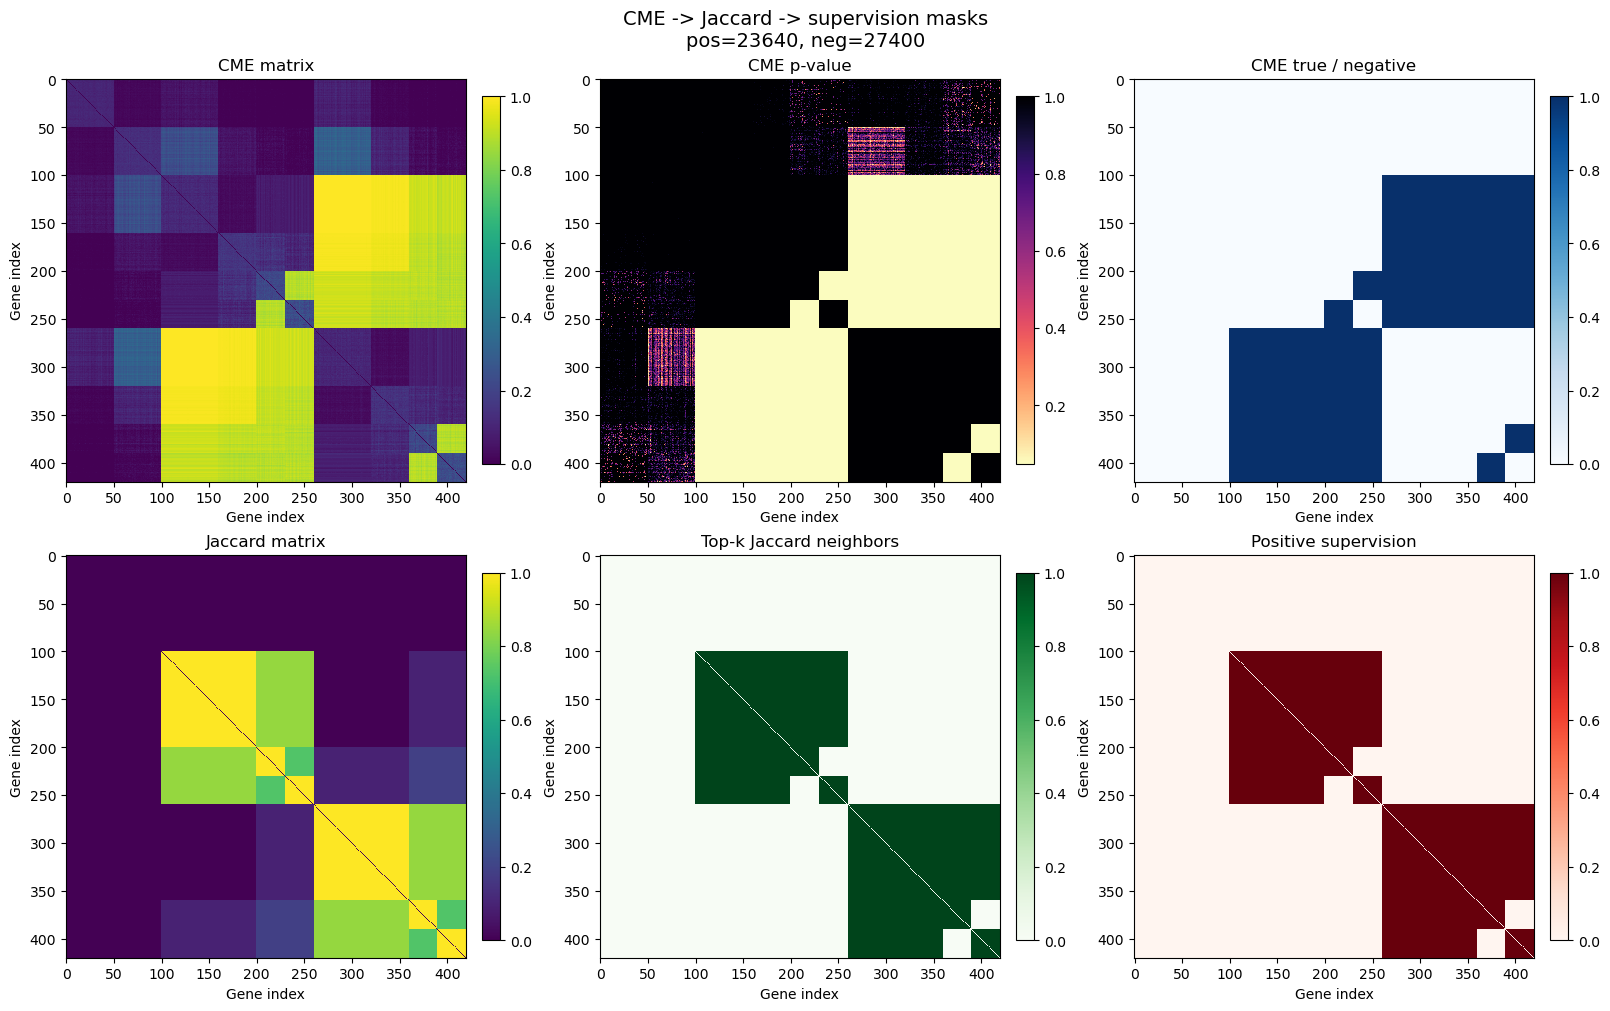

In [6]:
plot_cme_supervision_heatmaps(
    cme_matrix=cme_matrix,
    pval_matrix=pval_matrix,
    supervision=supervision,
    save_path=REPO_ROOT / "results/cme_supervision_heatmaps.png",
    show=True,
);

In [7]:
# ===== 正负监督 -> 超边 gene modules =====
result = run_supervised_hyperedges(
    adata_path=REPO_ROOT / "datasets/adata_672.h5ad",
    pos_mask=pos_mask,
    neg_mask=neg_mask,
    partial_pos_mask=None,
    num_hyperedges=num_hyperedges,
    use_unassigned_hyperedge=True,
    pos_strength=0.5,
    neg_strength=0.0,
    epochs=10000,
    lr=0.016,
    entropy_strength=0.001,
    device="auto",
    seed=seed,
)

partition = result.partition
hyperedge_emb = result.hyperedge_emb
gene_emb = result.gene_emb
losses = result.losses

summarize_unassigned_genes(result)

Epoch 1/10000, Loss: 0.140372962, pos(>= 0.5): 0.116750754, neg(->0): 0.021875925, Entropy: 1.7463
Epoch 100/10000, Loss: 0.011749906, pos(>= 0.5): 0.001760030, neg(->0): 0.008523775, Entropy: 1.4661
Epoch 200/10000, Loss: 0.004936013, pos(>= 0.5): 0.000813582, neg(->0): 0.002893044, Entropy: 1.2294
Epoch 300/10000, Loss: 0.001083194, pos(>= 0.5): 0.000029925, neg(->0): 0.000055511, Entropy: 0.9978
Epoch 400/10000, Loss: 0.000932055, pos(>= 0.5): 0.000000000, neg(->0): 0.000001251, Entropy: 0.9308
Epoch 500/10000, Loss: 0.000883196, pos(>= 0.5): 0.000000000, neg(->0): 0.000000868, Entropy: 0.8823
Epoch 600/10000, Loss: 0.000823614, pos(>= 0.5): 0.000000000, neg(->0): 0.000000656, Entropy: 0.8230
Epoch 700/10000, Loss: 0.000754967, pos(>= 0.5): 0.000000000, neg(->0): 0.000000530, Entropy: 0.7544
Epoch 800/10000, Loss: 0.000681887, pos(>= 0.5): 0.000000000, neg(->0): 0.000000440, Entropy: 0.6814
Epoch 900/10000, Loss: 0.000610021, pos(>= 0.5): 0.000000000, neg(->0): 0.000000361, Entropy:

{'num_gene_modules': 6,
 'num_hyperedges_total': 7,
 'null_hyperedge_index': 6,
 'supervised_genes': 320,
 'unassigned_genes': 100}

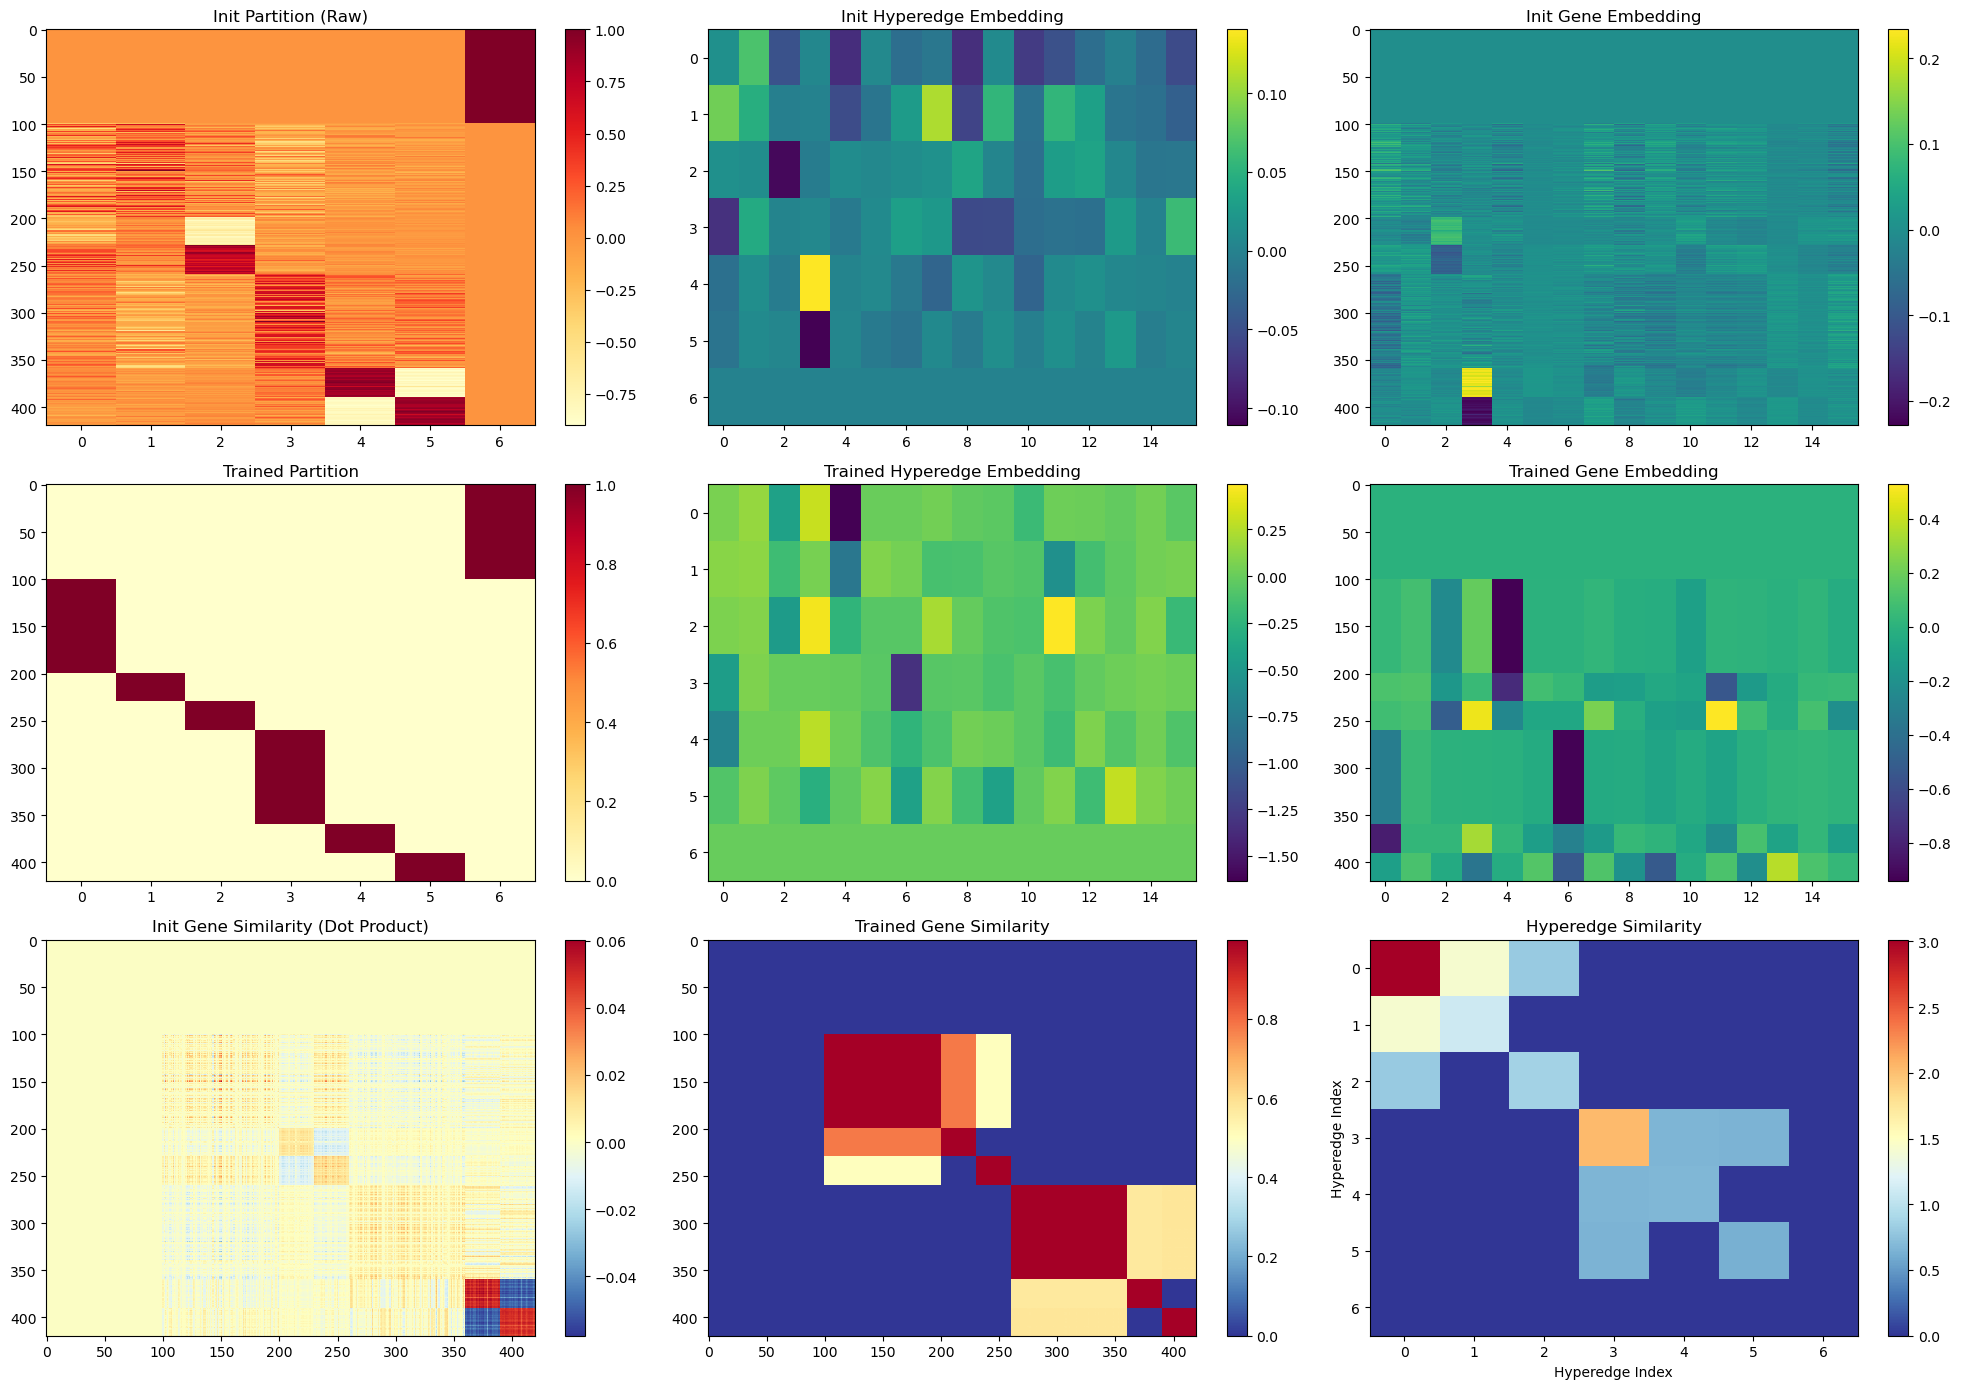

In [8]:
plot_run_summary(result);